# Вариант №21
Найти точку минимума функции
$$
f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75, \\
[x_1 = 0, x_2 = −3].
$$
методом Ньютона.
В окрестности точки минимума построить линии уровня и траекторию поиска (на одном графике). За своевременное выполнение задания начисляется 6 баллов.

Реализовав дополнительно следующие методы можно получить по 3 балла за каждый метод: 
- метод случайного поиска +
- метод Нелдера-Мида 
- метод Пауэлла +
- метод Хука-Дживса
- метод Розенброка +

Для того, чтобы лабораторная работа была засчитана требуется оформление отчета (с формулами) с описанием используемых методов в формате Jupyter+Markdown+LaTeX.

Найдём минимум функции аналитически. 
$$ f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75 = 2(x^2 + 2x) + 3(y^2 - 13y) =\\
 2(x+1)^2 + 3(y - 6,5)^2 + 1
$$
Функция представляет собой гиперболический парабалойд. Он имеет один минимум - вершину.
$$ x + 1 = 0,\\y - 6,5\\
x_0 = -1, \quad y_0 = 6,5\\f_{min} = f(-1, 6,5) = 1 $$

In [172]:
import matplotlib.pyplot as plt
import numpy as np

In [173]:
Y_MIN_BOUND = -50
Y_MAX_BOUND =  50
X_MIN_BOUND = -50
X_MAX_BOUND =  50

In [174]:
# def f(x1, x2):
#     return x1**2 + 4 * x1 + 3 * x2**2 - 39 * x2 + 129.75
# def f(xy):
#     return 2*xy[0]**4 + 4 * xy[0] + 3 * xy[1]**4 - 39 * xy[1] + 129.75

def f(x):
    """Целевая функция (например, функция Розенброка)"""
    # f(x,y) = (1-x)^2 + 100*(y-x^2)^2
    return np.array([(1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2])

def nabl(x):
    """Градиент функции"""
    dfdx1 = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dfdx2 = 200 * (x[1] - x[0]**2)
    return np.array([[dfdx1[0]], [dfdx2[0]]])

def Gesse(x):
    """Гессиан функции"""
    d2fdx1_2 = 2 - 400 * (x[1] - x[0]**2) + 800 * x[0]**2
    d2fdx1dx2 = -400 * x[0]
    d2fdx2dx1 = -400 * x[0]
    d2fdx2_2 = 200
    
    return np.array([[d2fdx1_2[0], d2fdx1dx2[0]],
                     [d2fdx2dx1[0], d2fdx2_2]])

In [175]:
x = np.linspace(-50, 50, 1000)
y = x
x, y = np.meshgrid(x,y)
# z = 2*x**4 + 4 * x + 3 * y**4 - 39 * y + 129.75
z = (1 - x)**2 + 100 * (y - x**2)**2

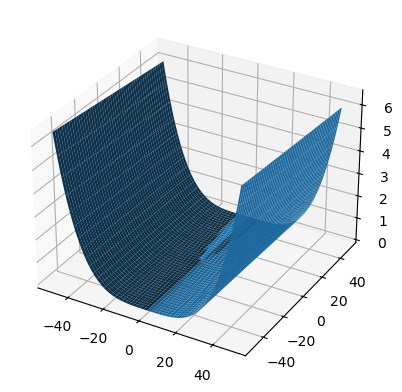

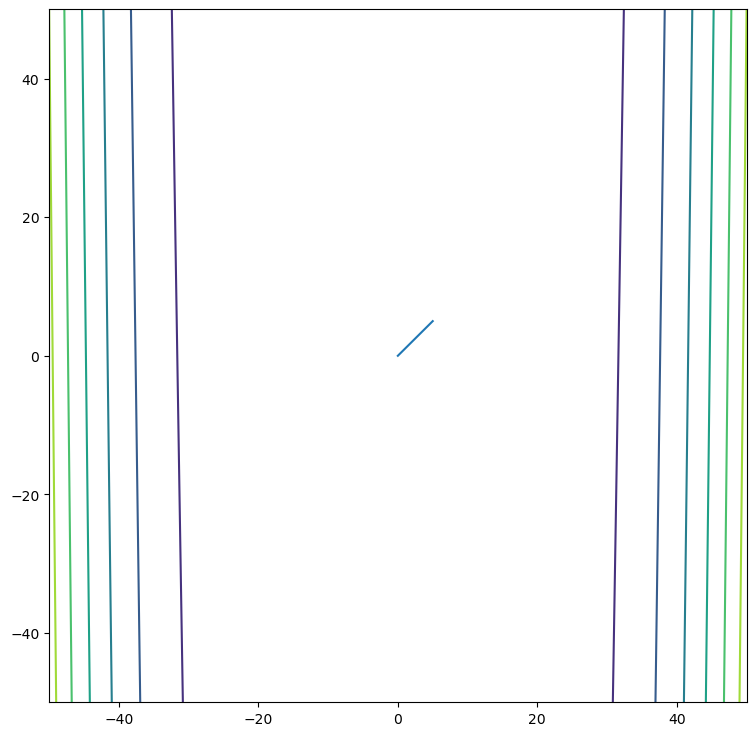

In [176]:
fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')
figu.plot_surface(x, y, z, label='sin')
# f.set(zlim=(0, 10))
# figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0,5], [0, 5])



# Метод случайного поиска
Идея: Генерируем $N$ точек в области определения функции и находим значение функции в этих точках, находим точку в которой функция принемает минимальное значение(назовём её "лучшая"), будем считать её минимумом функции.

In [177]:
def randomSearch(N):
    best = (X_MIN_BOUND, Y_MIN_BOUND)
    best_val = f(best)
    dots = []
    for _ in range(N):
        x = np.random.uniform(X_MIN_BOUND, X_MAX_BOUND)
        y = np.random.uniform(Y_MIN_BOUND, Y_MAX_BOUND)
        val = f((x, y))
        if val < best_val:
            best_val = val
            best = (x, y)
        dots.append((x, y))
    return best, dots

Результат работы Метода случайного поиска(N = 100):
Полученная точка: 
x = 4.040024502168279
y = 13.694933927310956
f_min = [699.28322312]


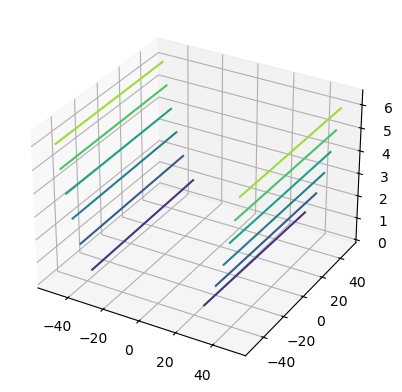

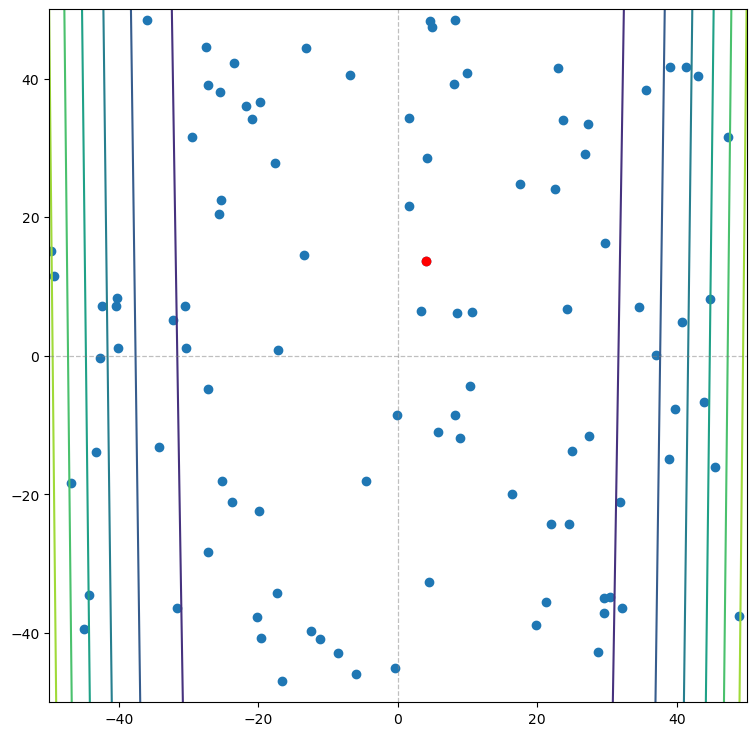

In [178]:
N = 100
res, dots = randomSearch(N)

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

# f.set(zlim=(0, 10))
figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

X_dots = [dot[0] for dot in dots]
Y_dots = [dot[1] for dot in dots]
plt.scatter(X_dots, Y_dots)
plt.scatter(res[0], res[1], color='red')


print(f'Результат работы Метода случайного поиска(N = {N}):')
print(f'Полученная точка: \nx = {res[0]}\ny = {res[1]}\nf_min = {f(res)}')

# Метод Ньютона
    return 2*xy[0]**4 + 4 * xy[0] + 3 * xy[1]**3 - 39 * xy[1] + 129.75
$$
f(x_1, x_2) = 2x^4_1 + 4x_1 + 3x^4_2 − 39.0x_2 + 129.75, \\
[x^0_1 = 0, x^0_2 = −3].
$$

Метод Ньютона для поиска экстремума функции:
$$ \vec{x}^{k+1} = \vec{x}^k + p^k $$

$$ p^k = -[\nabla^2 f(x^k)]^{-1} \nabla f(x^k) $$
Перейдём к системе линейных уравнений относительно $p^k$
$$ [\nabla^2 f(x^k)] p^k = -\nabla f(x^k) $$

Матрица Гессе - матрица, состоящая из вторых производных функции
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2 } \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2}
\end{pmatrix}
$$
Аналитически найдём часные производные функции $f$:

$ \frac{\partial f}{\partial x_1} =8x_1^3 + 4 $

$ \frac{\partial f}{\partial x_2} = 12x_2^3 - 39 $

$\frac{\partial^2 f}{\partial x_1^2} = 24x_1^2 $ 

$\frac{\partial^2 f}{\partial x_1 \partial x_2} = 0 $

$\frac{\partial^2 f}{\partial x_2^2} = 36x_2^2 $

$\frac{\partial^2 f}{\partial x_2 \partial x_1} = 0 $

Запишем матрицу Гессе и набла для нашей функции:
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
24x_1^2 & 0 \\
0 & 36x_2^2
\end{pmatrix} \\
\nabla f(x^k) = 
\begin{pmatrix}
8x_1^3 + 4 \\
12x_2^3- 39
\end{pmatrix}
$$

In [179]:
# def nabl(x):
#     res = np.zeros((2, 1))
#     res[0] = 8 * x[0]**3 + 4
#     res[1] = 36 * x[1]**2 - 39
#     return res

In [180]:
# def nabl(xy):
#     """Градиент функции (частные производные)"""
#     # df/dx1 = 8*x1^3 + 4
#     df_dx1 = 8 * xy[0]**3 + 4
#     # df/dx2 = 12*x2^3 - 39
#     df_dx2 = 12 * xy[1]**3 - 39
#     return np.array([[df_dx1[0]], [df_dx2[0]]]) if isinstance(xy, np.ndarray) and xy.shape == (2,1) else np.array([[df_dx1], [df_dx2]])

# # Вычисляем гессиан (вторые производные)
# def Gesse(xy):
#     """Гессиан функции (матрица вторых производных)"""
#     # d2f/dx1^2 = 24*x1^2
#     d2f_dx1_2 = 24 * xy[0]**2
#     # d2f/dx1dx2 = 0
#     d2f_dx1dx2 = 0
#     # d2f/dx2dx1 = 0
#     d2f_dx2dx1 = 0
#     # d2f/dx2^2 = 36*x2^2
#     d2f_dx2_2 = 36 * xy[1]**2
    
#     return np.array([[d2f_dx1_2[0] if isinstance(d2f_dx1_2, np.ndarray) else d2f_dx1_2, 
#                       d2f_dx1dx2],
#                      [d2f_dx2dx1, 
#                       d2f_dx2_2[0] if isinstance(d2f_dx2_2, np.ndarray) else d2f_dx2_2]])

In [181]:
# def Gesse(x):
#     g = np.zeros((2,2))

#     # np.array([
#     #     [24*x[0]**2, 0],
#     #     [0, 12*x[1]**2]
#     # ])
#     # g[0][0] = 24*x[0][0]**2
#     g[1][1] = 12*x[1][0]**2
#     return g

# Gesse((-40, 0)), np.linalg.inv([[12, 0], [0, 6]])

0 [[80.99100075]] norm 360467.6966442347
1 [[655823.0603957]] norm 17.999999894385137
2 [[2.02387212e-07]] norm 36229.691855806675
[[ 9.99950003]
 [99.99000056]] [9.99950003] [99.99000056]
[np.float64(9.999500027776232), np.float64(1.0004499024379214), np.float64(1.0004498746620178)] [np.float64(99.99000055552469), np.float64(-79.98200315106345), np.float64(1.0008999517112471)] 3 3
Найденный минимум:
x = 1.0004498746620178
y = 1.0008999517112471
f_min = [2.02387212e-07]
Итераций: 3


array([[1.00044987],
       [1.00089995]])

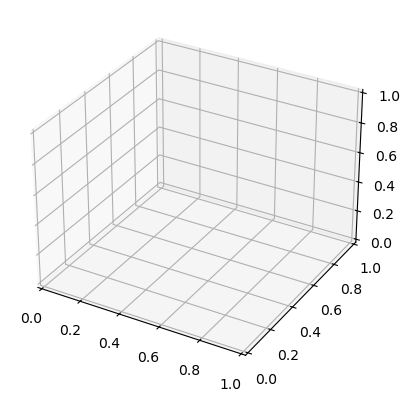

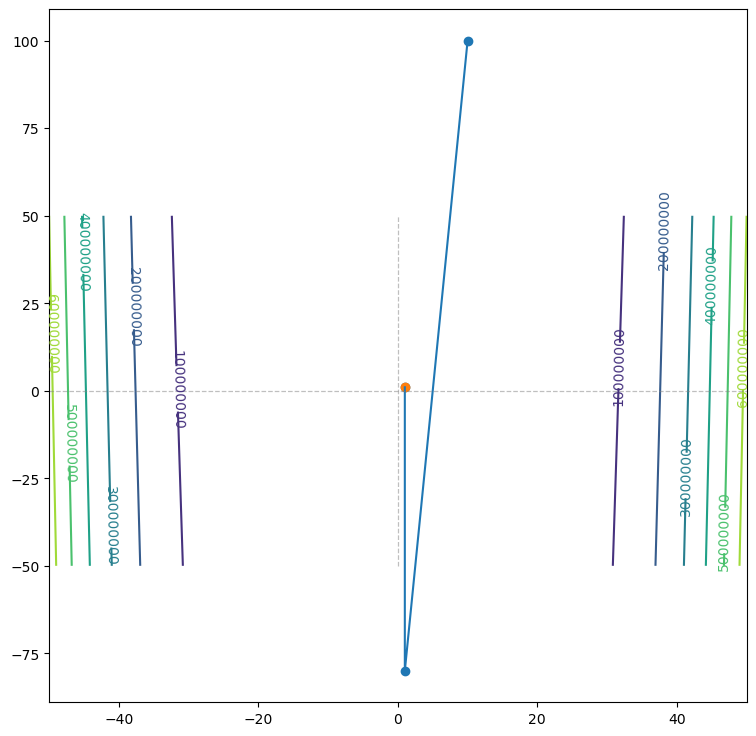

In [182]:
x_0 = np.zeros((2,1))
x_0[0] = 10
x_0[1] = 10
Eps = 0.001

x_current = x_0
x_next = x_0

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

# plt.xlim(-10, 10)
# plt.ylim(-10, 10)


# print(x_current, x_next, coef)

dots = []
iters = 0

while np.linalg.norm(nabl(x_next)) > Eps:

    x_current = x_next.copy()
    
    gesse = Gesse(x_current)
    
    # Добавляем регуляризацию для устойчивости
    if np.linalg.cond(gesse) > 1e10:
        gesse = gesse + np.eye(2) * 1e-6
    
    coef = -np.linalg.inv(gesse)
    p_k = np.dot(coef, nabl(x_current))
    
    # Обновляем x_next
    x_next = x_current + p_k
    
    dots.append(x_next.copy())


    print(iters, f(x_next),"norm", np.linalg.norm(nabl(x_current)))
    iters += 1

x_ = [dot[0][0] for dot in dots]
y_ = [dot[1][0] for dot in dots]
# x_.insert(x_0[0])
# y_.insert(x_0[1])
print(dots[0], dots[0][0], dots[0][1])
print(x_, y_, len(x_), len(y_))
plt.scatter(x_, y_)
plt.plot(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

result_dot = dots[-1]
# plt.scatter([-0.79370053],
#        [ 1.48124803])
plt.scatter(x_[-1], y_[-1])
print(f'Найденный минимум:\nx = {result_dot[0][0]}\ny = {result_dot[1][0]}\nf_min = {f(result_dot)[0]}\nИтераций: {iters}')
dots[-1]

In [183]:
f((-2, 6.5))

array([634.])

# Метод Розенброка

Идея метода заключается в том, что выбирается система ортогональных направлений $p^k_1 , p^k_2, ..., p^k_n$, в каждом из которых последовательно ищется минимальное значение, после чего система направлений поворачивается так, чтобы одна из осей совпала с направлением полного перемещения, а остальные были ортогональны между собой. Алгоритм Розенброка состоит из двух этапов:
## Покоординатный спуск. 

Пусть $x^k$ - вектор $k$-приближения и $p^k_1 , p^k_2, ..., p^k_n$ - система ортогональных направлений. На первой итерации это может быть ортонормированная система координат. Начиная с заданного $x^k$ последовательно осуществляем минимизацию функции $f(x)$ в направлениях, соответстствующих $p^k_1 , p^k_2, ..., p^k_n$, находя последовательные приближения:
$$
x^{k+1}_1 = x^k_1 + \lambda^k_1p^k_1, \qquad \lambda^k_1 = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_1) \\
\cdots \\
x^{k+1}_n = x^k_n + \lambda^k_n p^k_n, \qquad \lambda^k_n = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_n)
$$

In [184]:
def scalarMult(a, b):
    res = 0
    for i in range(len(a)):
        res += a[i] * b[i]
    return res

def proj(b, a):
    coef = scalarMult(a, b) / scalarMult(b, b)

    return  [coef * el for el in a]

In [185]:
# Реализация Алгоритма Грама-Шмидта (см. SLAU.ipynb)
def algGramSchmidt(a):
    vectors = [np.array(v, dtype=float) for v in a]
    orthogonal = []
    
    for i in range(len(vectors)):
        u = vectors[i].copy()
        
        for w in orthogonal:
            # Проекция v на w
            proj = np.dot(vectors[i], w) / np.dot(w, w) * w
            u = u - proj
        
        if np.linalg.norm(u) > 1e-10:
            u = u / np.linalg.norm(u)
            orthogonal.append(u)
        else:
            orthogonal.append(vectors[i].copy())

    return orthogonal

In [186]:
# Нахождение минимума относительно точки x в направлении p с помощью метода золотого сечения
def line_search(x, p, tol=1e-6):
    phi = (1 + np.sqrt(5)) / 2
    a, b = -50, 50  # начальный интервал
    
    while b - a > tol:
        c = b - (b - a) / phi
        d = a + (b - a) / phi
        if f(x + c*p) < f(x + d*p):
            b = d
        else:
            a = c
    return (a + b) / 2

[[1. 0.]
 [0. 1.]]
[[1. 0.]
 [0. 1.]]
a [[1.13405801e+03 1.13405801e+03]
 [1.77178173e-05 1.77178173e-05]] p =  [array([0.70710678, 0.70710678]), array([1.77178173e-05, 1.77178173e-05])]
[array([0.70710678, 0.70710678]), array([1.77178173e-05, 1.77178173e-05])]
[array([0.70710678, 0.70710678]), array([1.77178173e-05, 1.77178173e-05])]
a [[-4.15702818e-06 -4.15702818e-06]
 [-2.07851409e-06 -2.07851409e-06]] p =  [array([-0.70710678, -0.70710678]), array([-2.07851409e-06, -2.07851409e-06])]
[array([-0.70710678, -0.70710678]), array([-2.07851409e-06, -2.07851409e-06])]
[array([-0.70710678, -0.70710678]), array([-2.07851409e-06, -2.07851409e-06])]
a [[-4.18175064e-20 -4.18175064e-20]
 [-2.09087532e-20 -2.09087532e-20]] p =  [array([-4.18175064e-20, -4.18175064e-20]), array([-2.09087532e-20, -2.09087532e-20])]
Сошелся на итерации 3
Найденный минимум: x1 = 6.323830138564726, x2 = 39.995398349767875
Значение функции: [28.3452565]
Число итераций: 3


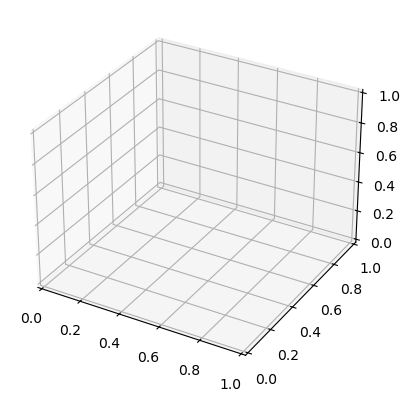

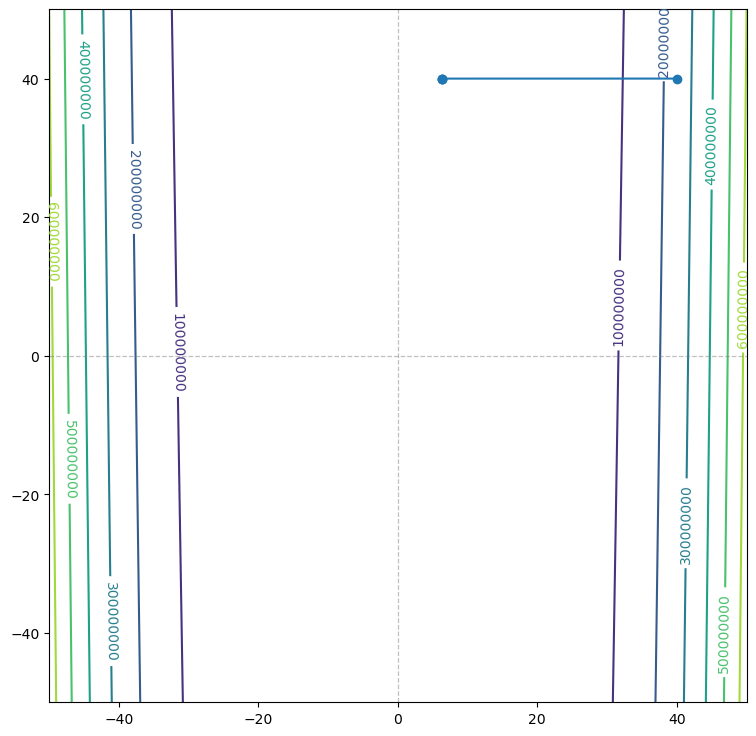

In [187]:
def Rozenbrock(x0, iters=100, eps=1e-6):
    x = np.array(x0, dtype=float)
    
    dots = [x0]
    p = np.eye(2)

    for iteration in range(iters):
        x_start = x.copy()
        lambdas = np.zeros(2)
        
        # Этап 1: покоординатный спуск вдоль направлений p
        for i in range(2):
            print(p)
            lam = line_search(x, p[i])
            lambdas[i] = lam
            x = x + lam * p[i]
        
        # Этап 2: построение новых направлений (поворот)
        
        # Сортируем lambdas по убыванию абсолютных значений
        idx = np.argsort(-np.abs(lambdas))

        p = [lambdas[ind] for ind in idx]
        
        # Строим векторы A_i
        A = []
        for i in range(2):
            vec = np.zeros(2)
            for j in range(i, 2):
                vec += lambdas[j] * p[j]
            A.append(vec)
        A = np.array(A)
        
        
        # Обновляем направления
        p = algGramSchmidt(A)
        print("a", A, "p = ", p)
        
        dots.append(x)

        # Проверка сходимости
        if np.linalg.norm(x - x_start) < eps:
            print(f"Сошелся на итерации {iteration+1}")
            break
        
    return x, f(x), iteration+1, dots

# Запуск
x0 = np.array([40, 40])  # далеко от минимума
x_min, f_min, iters, dots = Rozenbrock(x0)

print(f"Найденный минимум: x1 = {x_min[0]}, x2 = {x_min[1]}")
print(f"Значение функции: {f_min}")
print(f"Число итераций: {iters}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

# Метод Пауэлла

Последовательно выполнять одномерную минимизацию вдоль системы линейно независимых направлений, постепенно заменяя их на сопряжённые, что обеспечивает квадратичную сходимость.

In [188]:
def sumMult(x, y, b):
    return [x[i] + b * y[i] for i in range(2)] # x + b*y

[[-40, 40]]
[[-40, 40], array([ 6.32359128, 39.99203458])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147]), array([ 6.32279903, 39.98201474])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147]), array([ 6.32279903, 39.98201474]), array([-6.32251301, 39.97996207])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147]), array([ 6.32279903, 39.98201474]), array([-6.32251301, 39.97996207]), array([ 6.32200679, 39.97199648])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147]), array([ 6.32279903, 39.98201474]), array([-6.32251301, 39.97996207]), array([ 6.32200679, 39.97199648]), array([-6.32172076, 39.96994381])]
[[-40, 40], array([ 6.32359128, 39.99203458]), array([-6.32330525, 39.98998147]), array([ 6.32279903, 39.98201474]), array([-6.32251301, 39.97996207]), array([ 6.32200679, 39.971996

[[-40, 40],
 array([ 6.32359128, 39.99203458]),
 array([-6.32330525, 39.98998147]),
 array([ 6.32279903, 39.98201474]),
 array([-6.32251301, 39.97996207]),
 array([ 6.32200679, 39.97199648]),
 array([-6.32172076, 39.96994381]),
 array([ 6.32121454, 39.96197947]),
 array([-6.32092851, 39.95992696]),
 array([ 6.32042229, 39.95196378]),
 array([-6.32013627, 39.94991143])]

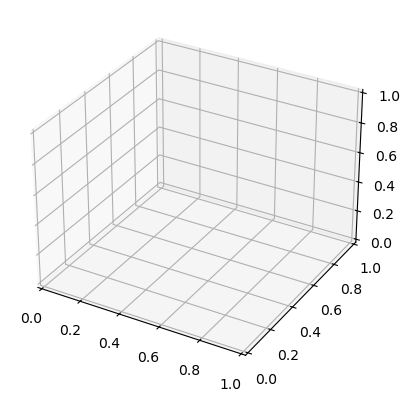

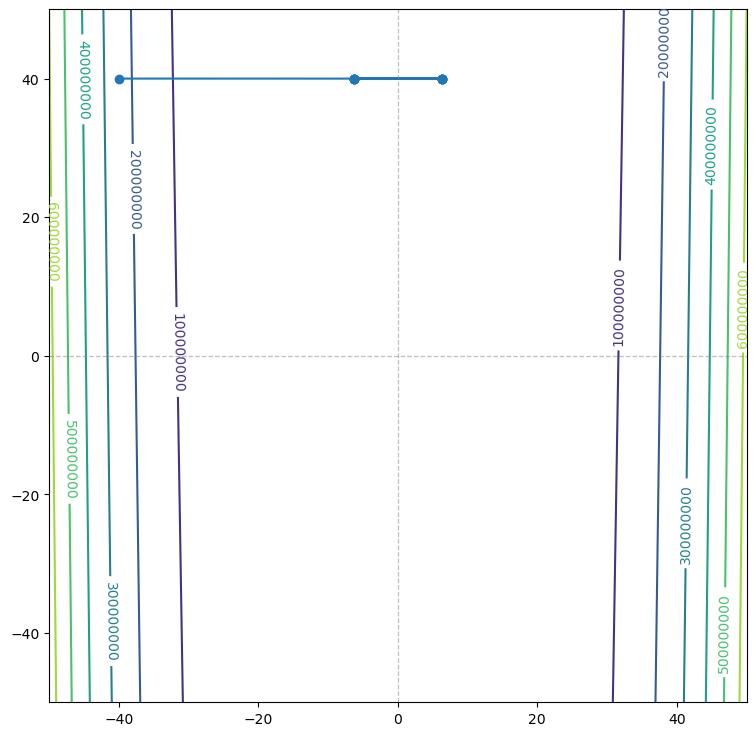

In [189]:
def powell(x0, iters=10, eps=1e-6):
    x = np.array(x0, dtype=float)
    
    dots = [x0]
    p = np.eye(2)  # начальные направления
    
    for iteration in range(iters):
        print(dots)
        x_start = x.copy()
        
        # Шаг 1: поиск вдоль всех направлений
        for i in range(2):
            lam = line_search(x, p[i])
            x = x + lam * p[i]
        
        x_end = x.copy()
        d_new = x_end - x_start
        
        # Шаг 2: проверка замены направлений
        x_test = 2*x_end - x_start
        if f(x_test) >= f(x_start):
            # не меняем направления
            pass
        else:
            # меняем направления
            
            p[0] = p[1]
            p[1] = d_new
            lam = line_search(x_end, p[1])
            x = x_end + lam * p[1]
        dots.append(x)
        # Шаг 3: проверка сходимости
        if np.linalg.norm(x - x_start) < eps:
            break
        
    return x, f(x), iteration, dots


x0 = [-40, 40]


x_min, f_min, it, dots = powell(x0)
print(f"Минимум в точке: {x_min}")
print(f"Значение функции: {f_min}")
print(f"Итераций: {it}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))

# plt.contour(x, y, z)

cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

dots

# Прим

Результатом стало нахождение минимума за одну итерацию. Это происходит из-за того что наша функция гладкая и градиент в любой точке направлен на точку локального минимума 